In [4]:
import numpy as np
import time

1. Сравнение производительности операций над массивами:


Напишите программу, которая:

- Генерирует два больших одномерных массива с 1 миллионом элементов каждый, заполненных случайными числами.

- Сначала выполняет поэлементное сложение этих массивов, используя циклы Python.

- Затем выполняет ту же операцию, используя возможности NumPy.

- Измеряет и выводит время выполнения каждого подхода.


Пример вывода:


Время выполнения сложения с использованием цикла Python: 0.5 секунды.

Время выполнения сложения с использованием NumPy: 0.01 секунды.

In [15]:
size = 100_000_000 # решил сделать 100 млн, а то как то быстро он их считает
arr1 = np.random.randint(-2**31, 2**31, size, dtype=np.int32)
arr2 = np.random.randint(-2**31, 2**31, size, dtype=np.int32)

# Сложение с помощью цикла Python
start = time.time()
result = []
for a, b in zip(arr1, arr2):
    result.append(int(a) + int(b))
end = time.time()
print("Время выполнения сложения с использованием цикла Python:", round(end - start, 3), "секунды.")

# Сложение с помощью NumPy
start = time.time()
result_np = arr1 + arr2
end = time.time()
print("Время выполнения сложения с использованием NumPy:", round(end - start, 3), "секунды.")

Время выполнения сложения с использованием цикла Python: 30.786 секунды.
Время выполнения сложения с использованием NumPy: 0.239 секунды.


Анализ расположения данных в памяти:

Создать большой двумерный массив и исследовать, как изменение порядка (C-style и Fortran-style) влияет на производительность операций сложения и умножения.

Можно использовать тот же бенчмарк что и в лекции. Необходимо погуглить про то, как завести массив с порядком в Fortran-style. Не забывайте про magic в jupyter.

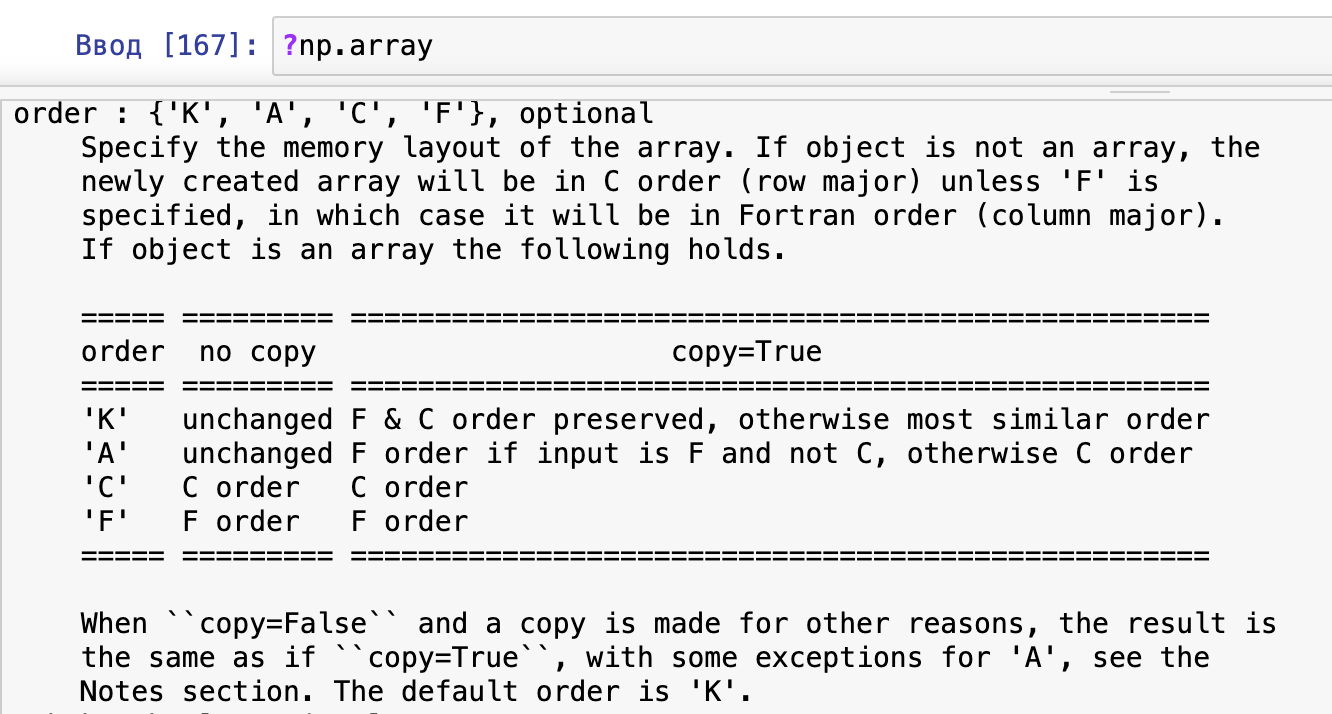

In [5]:
N = 10000  # размер матрицы (можно уменьшить, если не хватает памяти)

# Создаём одинаковые матрицы в разном порядке хранения
A_c = np.ones((N, N), order='C')  # C-style (по строкам)
A_f = np.ones((N, N), order='F')  # Fortran-style (по столбцам)

# Сложение по строкам
start = time.time()
sum_c_rows = A_c.sum(axis=1)
end = time.time()
print("C-order, сумма по строкам:", round(end - start, 3), "сек.")

start = time.time()
sum_f_rows = A_f.sum(axis=1)
end = time.time()
print("Fortran-order, сумма по строкам:", round(end - start, 3), "сек.")
print("----------------------------------------")
# Сложение по столбцам
start = time.time()
sum_c_cols = A_c.sum(axis=0)
end = time.time()
print("C-order, сумма по столбцам:", round(end - start, 3), "сек.")

start = time.time()
sum_f_cols = A_f.sum(axis=0)
end = time.time()
print("Fortran-order, сумма по столбцам:", round(end - start, 3), "сек.")
print("----------------------------------------")
# Умножение матриц
start = time.time()
prod_c_rows = A_c.prod(axis=1)
end = time.time()
print("C-order, произведение по строкам:", round(end - start, 3), "сек.")

start = time.time()
prod_f_rows = A_f.prod(axis=1)
end = time.time()
print("Fortran-order, произведение по строкам:", round(end - start, 3), "сек.")
print("----------------------------------------")
# Умножение по столбцам
start = time.time()
prod_c_cols = A_c.prod(axis=0)
end = time.time()
print("C-order, произведение по столбцам:", round(end - start, 3), "сек.")

start = time.time()
prod_f_cols = A_f.prod(axis=0)
end = time.time()
print("Fortran-order, произведение по столбцам:", round(end - start, 3), "сек.")

C-order, сумма по строкам: 0.183 сек.
Fortran-order, сумма по строкам: 0.054 сек.
----------------------------------------
C-order, сумма по столбцам: 0.048 сек.
Fortran-order, сумма по столбцам: 0.151 сек.
----------------------------------------
C-order, произведение по строкам: 0.092 сек.
Fortran-order, произведение по строкам: 0.049 сек.
----------------------------------------
C-order, произведение по столбцам: 0.041 сек.
Fortran-order, произведение по столбцам: 0.088 сек.


 Обратная матрица и определитель:

Напишите программу, которая:

- Запрашивает у пользователя размер квадратной матрицы N.

- Генерирует квадратную матрицу размером N x N, заполненную случайными числами от -10 до 10.

- Выводит сгенерированную матрицу на экран.

- Вычисляет и выводит определитель матрицы.

- Если определитель не равен нулю, программа должна вычислить и вывести обратную матрицу. В противном случае, программа должна сообщить, что обратной матрицы не существует.


Пример вывода:

Введите размер матрицы N: 3

Сгенерированная матрица:
[[ 1  2  3]
 [ 4  5  6]
 [-1 -2 -1]]

Определитель: -12

Обратная матрица:
[[...]
 [...]
 [...]]

In [14]:
N = int(input("Введите размер матрицы N x N: "))
arr = np.random.randint(-10, 10, size=(N, N))
print("Матрица:\n", arr)
print("----------------------------------------")
det = np.linalg.det(arr)
print("Определитель матрицы:", det)
print
if det != 0:
    inv_arr = np.linalg.inv(arr)
    print("Обратная матрица:\n", inv_arr)
else:
    print("Матрица вырождена, обратной матрицы не существует.")


Матрица:
 [[ -2  -4  -7  -3   8   7]
 [ -6   7  -8  -3   7   6]
 [  3  -4   9   5 -10   6]
 [ -4   5  -5   9  -9   0]
 [ -3  -9   2   7   6  -4]
 [ -6   3   6  -4   4  -3]]
----------------------------------------
Определитель матрицы: 1129214.9999999993
Обратная матрица:
 [[-0.15119618  0.10664842  0.01149294 -0.11379498  0.02975784 -0.15618549]
 [-0.16423976  0.15626874  0.01736339 -0.05811205  0.02176468 -0.06498143]
 [-0.08161599  0.06572796  0.05805095 -0.05805892  0.03349406  0.01246175]
 [-0.14484841  0.14543732  0.04115691 -0.03803527  0.10371364 -0.10307603]
 [-0.1235522   0.14833845  0.01344474 -0.09860036  0.08397161 -0.07668425]
 [ 0.00331558  0.07829598  0.07352984 -0.02739337  0.00291441 -0.02583122]]
